# Notebook 02 - Feature Engineering et Préparation pour la Modélisation

**Objectif** :  
Ce deuxième notebook transforme les données nettoyées en features optimisées pour le machine learning. L'objectif est de créer des variables pertinentes qui captent les relations complexes entre les caractéristiques des quartiers et les prix immobiliers.

**Livrables attendus** :
- Features géographiques avancées (gravity score, distances aux villes)
- Ratios métier pertinents (densité, occupation, pouvoir d'achat)
- Transformations logarithmiques pour normaliser les distributions
- Création de brackets sur la géographie et l'âge
- Deux datasets : un pour la modélisation ML, un pour les analyses business

## 1. Chargement du Dataset Nettoyé

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np
from scipy import stats

file_path = '../data/preprocessed/01_housing_cleaned.csv'

df = pd.read_csv(file_path)

print(f"Dimensions: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

print("Types de données:")
type_counts = df.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f"   - {dtype}: {count} colonnes")

print("\nValeurs manquantes:")
missing = df.isnull().sum()
if missing.sum() > 0:
    for col in missing[missing > 0].index:
        print(f"   • {col:25} {missing[col]:5}")
else:
    print("   Aucune valeur manquante")

cat_cols = df.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    print("\nVariables catégorielles:")
    for col in cat_cols:
        print(f"   - {col}: {df[col].nunique()} valeurs uniques")

Dimensions: 19,664 lignes × 10 colonnes
Types de données:
   - float64: 9 colonnes
   - object: 1 colonnes

Valeurs manquantes:
   Aucune valeur manquante

Variables catégorielles:
   - ocean_proximity: 5 valeurs uniques


**Informations** :
- Dataset : `01_housing_cleaned.csv`
- **19 664 lignes × 10 colonnes**
- Aucune valeur manquante
- Données cohérentes et prêtes pour l'enrichissement

**Vérification rapide** :
- Types de données OK (9 numériques + 1 catégorielle)
- Variable cible : `median_house_value`

## 2. Features Géographiques Avancées

**Villes POI (Points of Interest)** :
- **Los Angeles (LA)** / 3.88M / Hub économique
- **San Diego (SD)** / 1.40M / Tech + Biotech
- **San José (SJ)** / 0.99M / Silicon Valley
- **San Francisco (SF)** / 0.83M / Finance + Tech
- **Sacramento (SACR)** / 0.52M / Capitale
- **Fresno** / 0.54M / Agriculture
- **Long Beach (LB)** / 0.47M / Port
- **Oakland (OAK)** / 0.44M / Bay Area
- **Bakersfield (BAKER)** / 0.40M / Énergie
- **Anaheim (ANAH)** / 0.35M / Tourisme

### 2.1 Gravity Score : mesure de l'attractivité urbaine

**Formule** :  
`Gravity Score = Σ (Population ville / Distance²)`

**Principe** :  
Plus une ville est grande et proche, plus elle contribue au score d'attractivité du quartier.

In [3]:
cities = {
    'LA': (34.0522, -118.2437, 3.88),
    'SD': (32.7157,-117.1611, 1.4),
    'SJ': (37.3382,-121.8863, 0.99),
    'SF': (37.7749,-122.4194, 0.827),
    'SACR': (38.5816, -121.4944, 0.524),
    'FRESNO': (36.7378, -119.7871, 0.542),
    'LB': (33.7701, -118.1937, 0.466),
    'OAK': (37.8044,-122.2712, 0.440),
    'BAKER': (35.3733,-119.0187, 0.403),
    'ANAH': (33.8366,-117.9143, 0.346)
}

def calculate_gravity_score(lat, lon, cities):
    gravity = 0
    for city_name, (city_lat, city_lon, population) in cities.items():
        distance = np.sqrt((lat - city_lat)**2 + (lon - city_lon)**2)
        gravity += population / (distance + 1)  # +1 pour éviter division par 0
    
    return gravity

df['gravity_score'] = df.apply(lambda row : calculate_gravity_score(row['latitude'], row['longitude'], cities), axis=1)

print("Feature 'gravity_score' créée")
print(f"Nombre de valeurs manquantes dans gravity_score : {df['gravity_score'].isnull().sum()}\n")
print("Statistiques :")
print(df['gravity_score'].describe()[['mean', 'std', 'min', '50%', 'max']].round(3))

Feature 'gravity_score' créée
Nombre de valeurs manquantes dans gravity_score : 0

Statistiques :
mean    3.664
std     1.101
min     1.144
50%     3.366
max     5.722
Name: gravity_score, dtype: float64


**Interprétation** :
- **Gravity score élevé** = quartier proche de plusieurs grandes villes → attractivité forte → prix élevés attendus
- **Gravity score faible** = quartier isolé → prix plus bas

**Avantage** :  
Cette feature capture l'effet cumulé de plusieurs villes, contrairement à une simple distance à LA ou SF.

### 2.2 Distance à la ville la plus proche

**Complément au gravity score** :
- Mesure la distance euclidienne de la ville la plus proche parmi les 10 villes
- Utile pour identifier les quartiers vraiment isolés

In [4]:
def nearest_city_distance(lat, lon, cities):
    min_dist = float('inf')
    for city_name, (city_lat, city_lon, pop) in cities.items():
        dist = np.sqrt((lat - city_lat)**2 + (lon - city_lon)**2)
        min_dist = min(min_dist, dist)
    return min_dist

df['nearest_city_dist'] = df.apply(
    lambda row: nearest_city_distance(row['latitude'], row['longitude'], cities), 
    axis=1
)

print("Feature 'nearest_city_dist' créée")
print(f"Nombre de valeurs manquantes dans 'nearest_city_dist' : {df['nearest_city_dist'].isnull().sum()}\n")
print("Statistiques :")
print(df['nearest_city_dist'].describe()[['mean', 'std', 'min', '50%', 'max']].round(3))  

Feature 'nearest_city_dist' créée
Nombre de valeurs manquantes dans 'nearest_city_dist' : 0

Statistiques :
mean    0.422
std     0.528
min     0.004
50%     0.210
max     4.300
Name: nearest_city_dist, dtype: float64


**Interprétation** :
- Un quartier peut avoir un gravity score moyen mais être **très proche** d'une petite ville → `nearest_city_dist` sera faible
- Un quartier peut avoir un gravity score moyen mais n'être **proche d'aucune ville** → `nearest_city_dist` sera élevée

**Complémentarité** : Ces deux features capturent des aspects différents de la géographie.

### 2.3 Distances individuelles aux 5 principales villes

**Villes** : SF, LA, SD, SJ, Sacramento

**Note** :  
On utilise la **formule de Haversine** pour prendre en compte la courbure de la Terre. Retourne la distance entre deux points en km.

In [5]:
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    
    R = 6371 
    distance = R * c
    return distance

df['distance_to_sf'] = haversine(df['latitude'], df['longitude'], 37.7749, -122.4194)
df['distance_to_la'] = haversine(df['latitude'], df['longitude'], 34.0522, -118.2437)
df['distance_to_sd'] = haversine(df['latitude'], df['longitude'], 32.7157, -117.1611)
df['distance_to_sj'] = haversine(df['latitude'], df['longitude'], 37.3382, -121.8863)
df['distance_to_sacr'] = haversine(df['latitude'], df['longitude'], 38.5816, -121.4944)

print("Feature 'distance_to_..' créée")
print(f"Nombre de valeurs manquantes dans distance_to :\n{df[['distance_to_sf', 'distance_to_la', 'distance_to_sd', 'distance_to_sj', 'distance_to_sacr']].isnull().sum()}\n")
print(df[['distance_to_sf', 'distance_to_la', 'distance_to_sd', 'distance_to_sj', 'distance_to_sacr']].describe().T[['mean', 'std', 'min', '50%', 'max']].round(3))

Feature 'distance_to_..' créée
Nombre de valeurs manquantes dans distance_to :
distance_to_sf      0
distance_to_la      0
distance_to_sd      0
distance_to_sj      0
distance_to_sacr    0
dtype: int64

                     mean      std    min      50%       max
distance_to_sf    386.602  249.513  0.547  523.970   902.835
distance_to_la    271.772  248.018  0.420  177.124  1018.263
distance_to_sd    399.740  290.517  0.489  222.948  1196.922
distance_to_sj    349.650  216.726  0.383  457.908   836.448
distance_to_sacr  404.534  248.806  0.422  547.817   897.553


### 2.4 Brackets géographiques

**Objectif** :
- Découper la Californie en 5 zones (Nord-Sud et Est-Ouest)
- Permet au modèle de capturer des effets régionaux non linéaires

In [25]:
df['north_bracket'] = pd.qcut(df['latitude'], q=5, labels=False)
df['west_bracket'] = pd.qcut(df['longitude'], q=5, labels=False)
print(df.groupby('north_bracket')['latitude'].max())
print("Feature 'north_bracket' créée")
print(f"Nombre de valeurs manquantes dans north_bracket : {df['north_bracket'].isnull().sum()}\n")
print(df['north_bracket'].describe()[['mean', 'std', 'min', '50%', 'max']].round(3))
print()

print("Feature 'west_bracket' créée")
print(f"Nombre de valeurs manquantes dans west_bracket : {df['west_bracket'].isnull().sum()}\n")
print(df['west_bracket'].describe()[['mean', 'std', 'min', '50%', 'max']].round(3))
print()

north_bracket
0    33.87
1    34.10
2    36.70
3    37.84
4    41.95
Name: latitude, dtype: float64
Feature 'north_bracket' créée
Nombre de valeurs manquantes dans north_bracket : 0

mean    1.985
std     1.421
min     0.000
50%     2.000
max     4.000
Name: north_bracket, dtype: float64

Feature 'west_bracket' créée
Nombre de valeurs manquantes dans west_bracket : 0

mean    1.995
std     1.415
min     0.000
50%     2.000
max     4.000
Name: west_bracket, dtype: float64



**Méthode** : `pd.qcut` (quantiles)
- Chaque bracket contient ~20% des observations
- `north_bracket=0` : 20% des quartiers les plus au sud
- `north_bracket=4` : 20% des quartiers les plus au nord

**Interprétation** :  
Le modèle peut apprendre des relations linéaires **ET** des seuils régionaux (ex : effet Silicon Valley dans le nord).

## 3. Bracket Âge Médian

In [14]:
bins = [0, 10, 20, 30, 40, 50, float('inf')]

labels = ['1-10', '11-20', '21-30', '31-40', '41-50', '>50']

df['housing_median_age_bracket'] = pd.cut(
    df['housing_median_age'],
    bins=bins,
    labels=labels,
    right=True  
)

value_counts = df['housing_median_age_bracket'].value_counts().sort_index()
print(value_counts)

housing_median_age_bracket
1-10     1520
11-20    4613
21-30    4633
31-40    5330
41-50    2423
>50      1145
Name: count, dtype: int64


**Résultats** :
- **6 catégories d'âge** créées
- Permet de capturer le plafond fixé par le dataset sur `housing_median_age` (52 ans)

**Utilité** :  
Transformer une variable continue en catégories facilite l'interprétation et permet au modèle de détecter des seuils.

## 4. Encodage des Variables Catégorielles

### 4.1 Encodage de ocean_proximity

In [15]:
proximity_order = {
    'ISLAND': 5,       # Prix le plus élevé
    '<1H OCEAN': 4,    
    'NEAR BAY': 3,      
    'NEAR OCEAN': 2,    
    'INLAND': 1        # Prix le plus bas
}
df['ocean_proximity_encoded'] = df['ocean_proximity'].map(proximity_order)

print("Encodage vérifié :")
print(df.groupby('ocean_proximity')['ocean_proximity_encoded'].first().sort_values(ascending=False))

Encodage vérifié :
ocean_proximity
ISLAND        5
<1H OCEAN     4
NEAR BAY      3
NEAR OCEAN    2
INLAND        1
Name: ocean_proximity_encoded, dtype: int64


**Pourquoi ordinal et pas one-hot ?**
- Il existe une **relation ordonnée claire** : plus on est proche de l'océan, plus c'est cher
- L'encodage ordinal permet au modèle de capturer cet effet linéaire

**Mapping** :
- 1 = `INLAND` (le moins cher)
- 2 = `<1H OCEAN`
- 3 = `NEAR OCEAN`
- 4 = `NEAR BAY`
- 5 = `ISLAND` (le plus cher)

### 4.2 Encodage de housing_median_age_bracket

In [16]:
ordinal_mapping = {'1-10': 1, '11-20': 2, '21-30': 3, '31-40': 4, '41-50': 5, '>50': 6}
df['housing_median_age_bracket_encoded'] = df['housing_median_age_bracket'].map(ordinal_mapping).astype(int)

print("Encodage vérifié :")
print(df.groupby('housing_median_age_bracket', observed=True)['housing_median_age_bracket_encoded'].first().sort_values(ascending=False))

Encodage vérifié :
housing_median_age_bracket
>50      6
41-50    5
31-40    4
21-30    3
11-20    2
1-10     1
Name: housing_median_age_bracket_encoded, dtype: int32


**Pourquoi ordinal ?**
- Il y a un ordre logique : les tranches plus grandes correspondent à des maisons plus anciennes
- Capture la progression : maisons neuves → récentes → anciennes → très anciennes

**Mapping** :  
0 = 1-10 ans → 5 = >50 ans

## 5. Features Métier : Ratios et Densités

### 5.1 Vérification préalable (division par zéro)

In [17]:
print(f"Valeurs egales à 0 ou manquantes dans 'households' : {(df['households'] == 0 | df['households'].isnull()).sum()}")
print(f"Valeurs egales à 0 ou manquantes dans 'total_rooms' : {(df['total_rooms'] == 0 | df['total_rooms'].isnull()).sum()}")
print(f"Valeurs egales à 0 ou manquantes dans 'population' : {(df['population'] == 0 | df['population'].isnull()).sum()}")
print(f"Valeurs egales à 0 ou manquantes dans 'median_income' : {(df['median_income'] == 0 | df['median_income'].isnull()).sum()}")

Valeurs egales à 0 ou manquantes dans 'households' : 0
Valeurs egales à 0 ou manquantes dans 'total_rooms' : 0
Valeurs egales à 0 ou manquantes dans 'population' : 0
Valeurs egales à 0 ou manquantes dans 'median_income' : 0


### 5.2 Création des features structurelles

**Features créées** :
- `room_per_house` : Taille moyenne des logements (total_rooms / households)
- `bedroom_per_house` : Nombre de chambres par logement
- `population_per_house` : Taille des ménages par logement
- `bedroom_pct` : % de chambres vs. autres pièces
- `total_other_rooms` : Salons, cuisines, bureaux, etc.
- `other_rooms_pct` : % d'espaces de vie non-chambres

3.675382816314076 3.0956362742748995


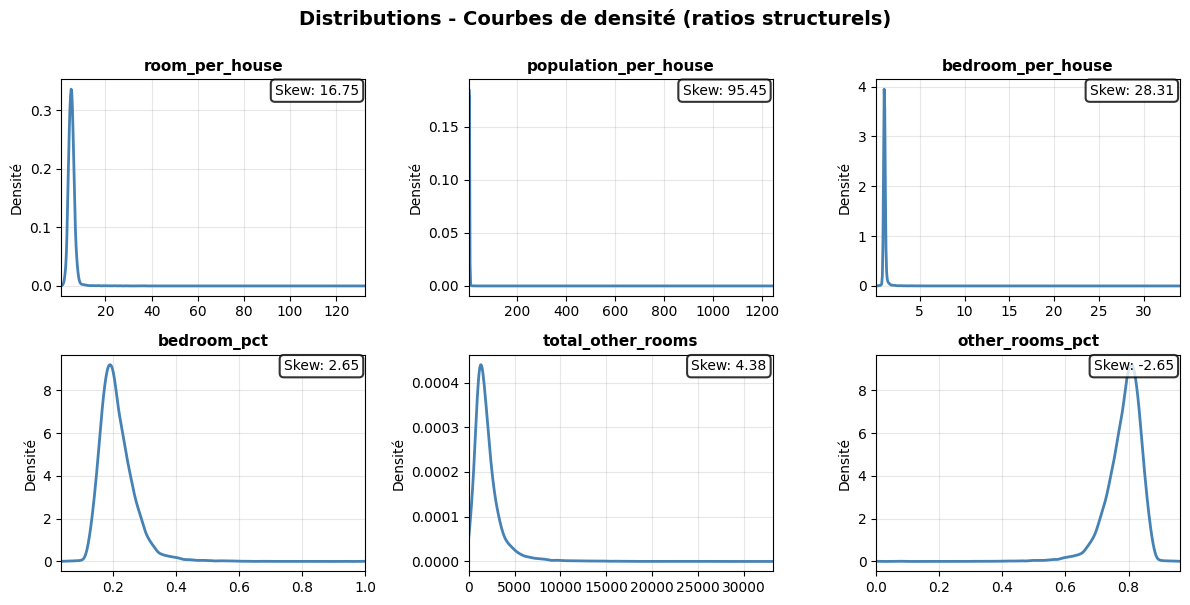

In [28]:
df['room_per_house'] = df['total_rooms'] / df['households']
df['population_per_house'] = df['population'] / df['households']
df['bedroom_per_house'] = df['total_bedrooms'] / df['households']
df['bedroom_pct'] = df['total_bedrooms'] / df['total_rooms']
df['total_other_rooms'] = df['total_rooms'] - df['total_bedrooms']
df['other_rooms_pct'] = df['total_other_rooms'] / df['total_rooms']


cols_struct = [
    'room_per_house', 'population_per_house', 'bedroom_per_house', 'bedroom_pct', 'total_other_rooms', 'other_rooms_pct'
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, cols in enumerate(cols_struct):
    df[cols].plot(kind='kde', ax=axes[i], color='steelblue', linewidth=2)
    axes[i].set_title(f"{cols}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Densité")
    axes[i].set_xlabel("")
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim(df[cols].min(), df[cols].max())
    skew = df[cols].skew()
    axes[i].text(0.98, 0.98, f'Skew: {skew:.2f}',
                transform=axes[i].transAxes,
                fontsize=10,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', 
                         edgecolor='black', linewidth=1.5, alpha=0.8))
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions - Courbes de densité (ratios structurels)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Hypothèses** :
- Plus de `room_per_house` = logements spacieux = prix élevés
- `population_per_house` élevé = suroccupation = quartiers populaires = prix plus bas
- `bedroom_pct` faible = grands espaces de vie = standing élevé

**Logique métier** :  
Ces ratios capturent la **qualité du logement** mieux que les valeurs brutes.

### 5.3 Création des features de pouvoir d'achat

**Features créées** :
- `income_per_person` : Pouvoir d'achat individuel (income / population)
- `income_age_interaction` : Quartiers riches + anciens = prestige
- `income_rooms_interaction` : Revenus élevés + logements spacieux
- `gravity_income` : Attractivité urbaine + richesse
- `income_to_rooms_ratio` : Densité de richesse par m²

**Logique** :  
Ces interactions capturent des **effets synergiques** entre variables.

count    19664.000000
mean         1.324475
std          0.626003
min          0.008225
25%          0.849075
50%          1.257604
75%          1.705009
max          7.462508
Name: income_per_person, dtype: float64


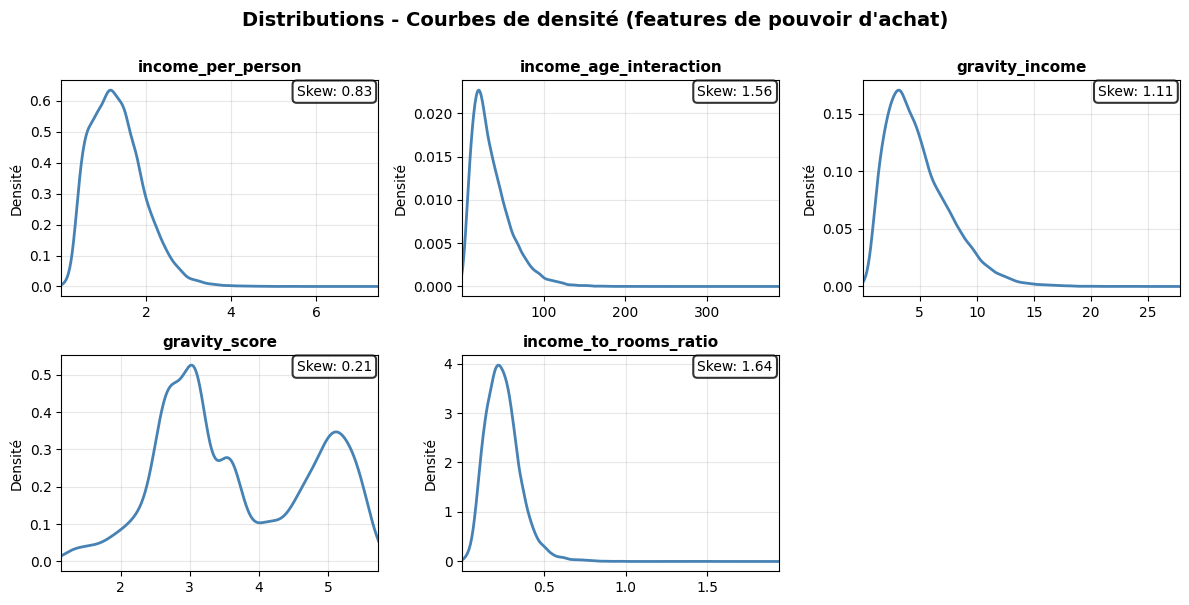

In [26]:
df['income_per_person'] = df['median_income'] / df['population_per_house']
print(df['income_per_person'].describe())
df['income_age_interaction'] = df['income_per_person'] * df['housing_median_age']
df['income_rooms_interaction'] = df['income_per_person'] * df['room_per_house']
df['gravity_income'] = df['gravity_score'] * df['income_per_person']
df['income_to_rooms_ratio'] = df['income_per_person'] / (df['room_per_house'])

columns_income = [
    'income_per_person', 'income_age_interaction', 'gravity_income', 'gravity_score', 'income_to_rooms_ratio'
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, cols in enumerate(columns_income):
    df[cols].plot(kind='kde', ax=axes[i], color='steelblue', linewidth=2)
    axes[i].set_title(f"{cols}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Densité")
    axes[i].set_xlabel("")
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim(df[cols].min(), df[cols].max())
    skew = df[cols].skew()
    axes[i].text(0.98, 0.98, f'Skew: {skew:.2f}',
                transform=axes[i].transAxes,
                fontsize=10,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', 
                         edgecolor='black', linewidth=1.5, alpha=0.8))
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions - Courbes de densité (features de pouvoir d\'achat)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 5.4 Création features d'interaction géographie × économie

**Features créées** :
- `income_bracket` : Catégorisation richesse (0=pauvre, 4=riche)
- `gravity_ocean` : Urbanité + côte = double attractivité
- `gravity_ocean_squared` : Capture des effets non linéaires
- `income_per_person_squared` : Capture des effets non linéaires du revenu
- `income_gravity_product` : Revenu × ville × océan
- `age_income_ratio` : Vieux quartiers pauvres vs. neufs riches

**Objectif** :  
Modéliser des relations complexes que le modèle ne pourrait pas détecter seul.

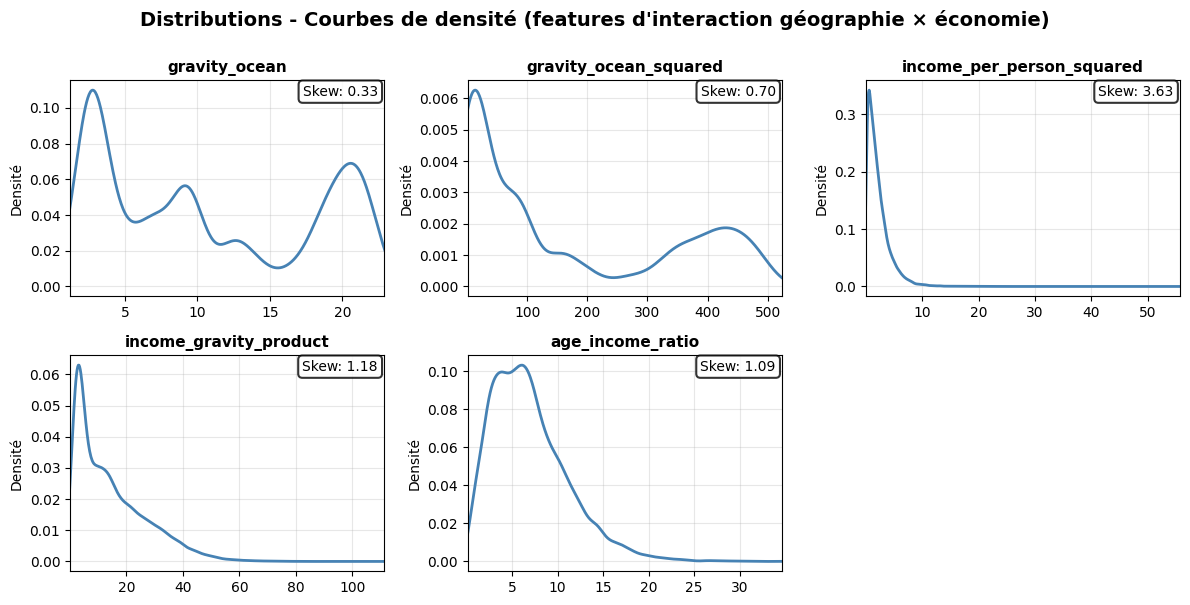

In [22]:
df['income_bracket'] = pd.qcut(df['income_per_person'], q=5, labels=False)
df['gravity_ocean'] = df['gravity_score'] * df['ocean_proximity_encoded']
df['gravity_ocean_squared'] = df['gravity_ocean'] ** 2
df['income_per_person_squared'] = df['income_per_person'] ** 2
df['income_gravity_product'] = df['income_per_person'] * df['gravity_ocean']
df['age_income_ratio'] = df['housing_median_age'] / (df['median_income'] + 1)

columns_num = [
    'gravity_ocean', 'gravity_ocean_squared', 'income_per_person_squared', 'income_gravity_product', 'age_income_ratio'
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, cols in enumerate(columns_num):
    df[cols].plot(kind='kde', ax=axes[i], color='steelblue', linewidth=2)
    axes[i].set_title(f"{cols}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Densité")
    axes[i].set_xlabel("")
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim(df[cols].min(), df[cols].max())
    skew = df[cols].skew()
    axes[i].text(0.98, 0.98, f'Skew: {skew:.2f}',
                transform=axes[i].transAxes,
                fontsize=10,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', 
                         edgecolor='black', linewidth=1.5, alpha=0.8))
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions - Courbes de densité (features d\'interaction géographie × économie)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Observations graphiques** :
- Beaucoup de nouvelles features restent **asymétriques** (skew >> 1)

**Variables à skew critique** :
- **Structurel** : `room_per_house`, `population_per_house`, `bedroom_per_house`, `total_other_rooms`
- **Pouvoir d'achat** : `income_age_interaction`, `income_to_rooms_ratio`
- **Géographie × économie** : `income_per_person_squared`, `income_gravity_product`

**Action requise** :  
Appliquer des **transformations logarithmiques** aux features asymétriques pour diminuer l'influence des valeurs extrêmes.

## 6. Transformations Logarithmiques

**Variables de base à transformer** :
- `total_rooms`, `total_bedrooms`, `population`, `households`

**Variables dérivées à transformer** :
- **Structurel** : `room_per_house`, `population_per_house`, `bedroom_per_house`, `total_other_rooms`
- **Pouvoir d'achat** : `income_age_interaction`, `income_to_rooms_ratio`
- **Géographie × économie** : `income_per_person_squared`, `income_gravity_product`

### 6.1 Transformations

**Formule** :  
`np.log1p(x)` = `log(1 + x)`

**Objectif** :
- Évite `log(0)` si jamais une valeur est nulle
- Compresse les grandes valeurs et étale les petites
- Rend les distributions plus symétriques

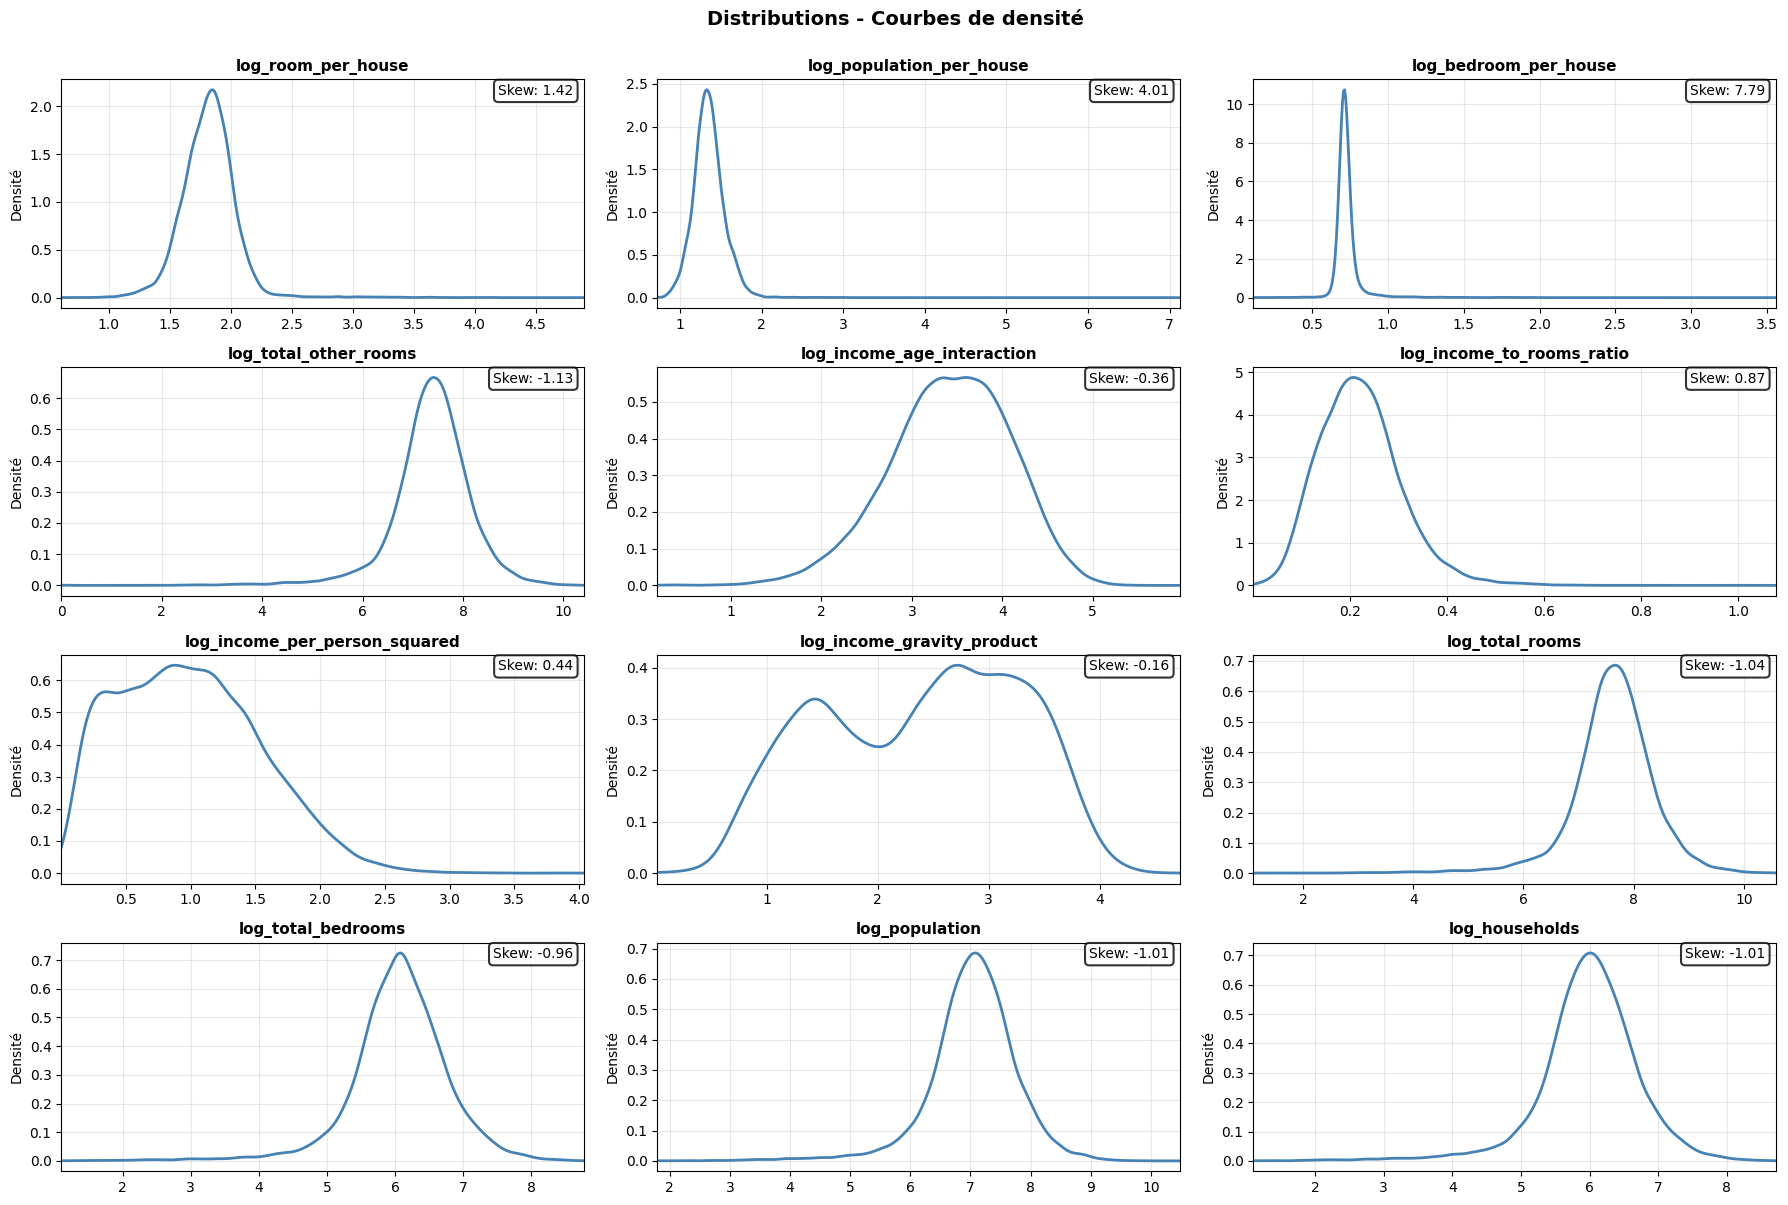

In [57]:
columns_to_log = [
    'room_per_house', 'population_per_house', 'bedroom_per_house', 
    'total_other_rooms', 'income_age_interaction', 'income_to_rooms_ratio',
    'income_per_person_squared', 'income_gravity_product', 'total_rooms', 'total_bedrooms',
    'population', 'households'  
]

for col in columns_to_log:
    df[f"log_{col}"] = np.log1p(df[col])

fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes = axes.flatten()

for i, cols in enumerate(columns_to_log):
    df[f"log_{cols}"].plot(kind='kde', ax=axes[i], color='steelblue', linewidth=2)
    axes[i].set_title(f"log_{cols}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Densité")
    axes[i].set_xlabel("")
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim(df[f"log_{cols}"].min(), df[f"log_{cols}"].max())
    skew = df[f"log_{cols}"].skew()
    axes[i].text(0.98, 0.98, f'Skew: {skew:.2f}',
                transform=axes[i].transAxes,
                fontsize=10,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', 
                         edgecolor='black', linewidth=1.5, alpha=0.8))
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions - Courbes de densité', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Résultats** :
- **Skewness drastiquement réduit** sur toutes les variables
- Distributions plus symétriques et proches de la normale
- Les outliers extrêmes sont compressés

**Exemple** :  
`room_per_house` :
- Avant : skew = **16.75**
- Après : skew = **1.42**

**Impact attendu** :  
Le modèle XGBoost sera plus stable et performant avec ces distributions normalisées.

## 7. Préparation des Datasets Finaux

**Problème** :
- On a maintenant des variables en double (ex : `total_rooms` ET `log_total_rooms`)
- Pour la modélisation, garder les deux serait redondant et causerait du bruit

**Solution : 2 datasets distincts**

#### Dataset 1 : `df_model` (pour le ML)
**Colonnes supprimées** :
- Variables originales transformées en log (`total_rooms`, `population`, etc.)
- Variables remplacées par des encodages (`ocean_proximity`, `housing_median_age_bracket`)

**Colonnes conservées** :
- Toutes les features transformées (`log_*`)
- Toutes les features d'interaction
- Tous les encodages et brackets
- Variable cible : `median_house_value`

#### Dataset 2 : `df_metier` (pour analyses business)
**Colonnes conservées** :
- **Toutes** les variables (originales + transformées + features)
- Permet des analyses métier avec noms de colonnes compréhensibles
- Facilite l'interprétation et la communication

In [58]:
features_to_drop = [
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'room_per_house',
    'population_per_house',
    'total_other_rooms',
    'income_age_interaction',
    'income_to_rooms_ratio',
    'income_gravity_product',
    'income_per_person_squared',
    'bedroom_per_house',
    'ocean_proximity',
    'housing_median_age_bracket'
]

df_model = df.drop(columns=features_to_drop).copy()
df_metier = df.copy()

print("Dataset modèle :\n")
print(f"  • Dimensions : {df_model.shape}")
print(f"  • Valeurs manquantes : {df_model.isnull().sum().sum()}")
print("  • Variables :")
for col in df_model.columns:
    print(f"      - {col} : {df_model[col].dtype}")

print("\nDataset métier :\n")
print(f"  • Dimensions : {df_metier.shape}")
print(f"  • Valeurs manquantes : {df_metier.isnull().sum().sum()}")
print("  • Variables :")
for col in df_metier.columns:
    print(f"      - {col} : {df_metier[col].dtype}")

Dataset modèle :

  • Dimensions : (19664, 37)
  • Valeurs manquantes : 0
  • Variables :
      - longitude : float64
      - latitude : float64
      - housing_median_age : float64
      - median_income : float64
      - median_house_value : float64
      - gravity_score : float64
      - nearest_city_dist : float64
      - distance_to_sf : float64
      - distance_to_la : float64
      - distance_to_sd : float64
      - distance_to_sj : float64
      - distance_to_sacr : float64
      - north_bracket : int64
      - west_bracket : int64
      - housing_median_age_bracket_encoded : int32
      - bedroom_pct : float64
      - other_rooms_pct : float64
      - income_per_person : float64
      - income_rooms_interaction : float64
      - gravity_income : float64
      - income_bracket : int64
      - ocean_proximity_encoded : int64
      - gravity_ocean : float64
      - gravity_ocean_squared : float64
      - age_income_ratio : float64
      - log_room_per_house : float64
      - log_p

## 8. Analyse de Corrélation avec la Cible

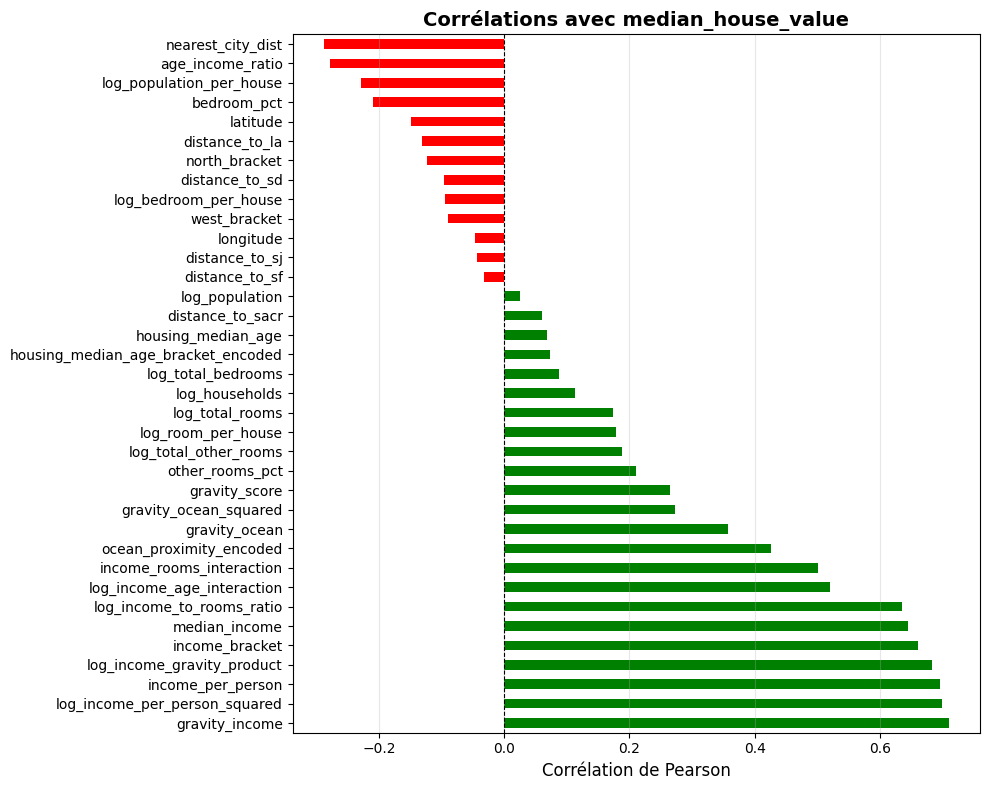

median_house_value                    1.000000
gravity_income                        0.709942
log_income_per_person_squared         0.698377
income_per_person                     0.696067
log_income_gravity_product            0.683578
income_bracket                        0.660873
median_income                         0.644718
log_income_to_rooms_ratio             0.636022
log_income_age_interaction            0.520192
income_rooms_interaction              0.501455
ocean_proximity_encoded               0.426551
gravity_ocean                         0.356971
gravity_ocean_squared                 0.272612
gravity_score                         0.264088
other_rooms_pct                       0.210163
log_total_other_rooms                 0.187481
log_room_per_house                    0.178294
log_total_rooms                       0.173564
log_households                        0.112750
log_total_bedrooms                    0.088198
housing_median_age_bracket_encoded    0.073025
housing_media

In [59]:
target_var = 'median_house_value'
correlations = df_model.corr(method='pearson')[target_var].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlations.drop(target_var).plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlations.drop(target_var)])
plt.xlabel('Corrélation de Pearson', fontsize=12)
plt.title(f'Corrélations avec {target_var}', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(correlations)

**Observations** :
- Les variables liées aux **revenus dominent largement** : cela confirme que le revenu reste le facteur explicatif principal
- Les variables **issues du feature engineering** renforcent le signal explicatif par rapport aux variables originales
- Les variables géographiques ont un impact **secondaire** par rapport au revenu

**Résultats** :
- Les corrélations confirment que les variables issues du feature engineering (interactions, ratios, transformations logarithmiques) **expliquent mieux** le prix médian des logements que les variables brutes
- Les facteurs **économiques dominent largement** les facteurs géographiques
- Les **transformations logarithmiques** ont permis de révéler des corrélations cachées

**Top 5 features** (par corrélation avec `median_house_value`) :
1. Variables de revenu et interactions
2. Transformations logarithmiques
3. Features d'interaction complexes
4. Variables géographiques avancées
5. Ratios métier

## 9. Validation Finale

In [60]:
target = 'median_house_value'

print("Vérification des datasets\n")

print(f"Dimensions")
print(f"  • df_model  : {df_model.shape}")
print(f"  • df_metier : {df_metier.shape}\n")

print(f"Valeurs manquantes")
print(f"  • df_model  : {df_model.isnull().sum().sum()}")
print(f"  • df_metier : {df_metier.isnull().sum().sum()}\n")

print(f"Types de données")
print(f"  • df_model  : {'All numeric' if df_model.select_dtypes(exclude='number').empty else 'Mix'}")
print(f"  • df_metier : {'All numeric' if df_metier.select_dtypes(exclude='number').empty else 'Mix (avec catégorielles)'}\n")

print(f"Variable cible présente")
print(f"  • df_model  : {target in df_model.columns}")
print(f"  • df_metier : {target in df_metier.columns}")

print(df_model.select_dtypes(exclude='number').columns)

Vérification des datasets

Dimensions
  • df_model  : (19664, 37)
  • df_metier : (19664, 51)

Valeurs manquantes
  • df_model  : 0
  • df_metier : 0

Types de données
  • df_model  : All numeric
  • df_metier : Mix (avec catégorielles)

Variable cible présente
  • df_model  : True
  • df_metier : True
Index([], dtype='object')


## 10. Sauvegarde des Datasets

In [61]:
df_model.to_csv('../data/preprocessed/02_housing_model.csv', index=False)
df_metier.to_csv('../data/preprocessed/02_housing_metier.csv', index=False)

print("Datasets sauvegardés")
print(f"Fichiers : ../data/preprocessed/02_housing_model.csv et ../data/preprocessed/02_housing_metier.csv")

Datasets sauvegardés
Fichiers : ../data/preprocessed/02_housing_model.csv et ../data/preprocessed/02_housing_metier.csv


**Résultats** :
- **Deux fichiers CSV créés** :
  - `../data/preprocessed/02_housing_model.csv` → pour le machine learning
  - `../data/preprocessed/02_housing_metier.csv` → pour les analyses business

**Dimensions** :
- 19 664 lignes (inchangé)
- `df_model` : ~45 colonnes (features optimisées pour ML)
- `df_metier` : ~60 colonnes (toutes les variables)

## Synthèse

### 1. Features géographiques avancées
- **Gravity score** : mesure d'attractivité urbaine
- **Distances aux 5 principales villes** (SF, LA, SD, SJ, Sacramento)
- **Brackets géographiques** (zones Nord/Sud et Est/Ouest)

### 2. Features métier pertinentes
- **Ratios structurels** : chambres, densité, occupation
- **Features de pouvoir d'achat** : `income_per_person`, interactions
- **Interactions complexes** : géographie × économie
- **Brackets sur l'âge médian** des maisons

### 3. Transformations statistiques
- **Transformations logarithmiques** sur 12+ variables
- **Réduction drastique de l'asymétrie** (skew divisé par 10+)
- **Distributions normalisées** pour améliorer les performances ML

### 4. Encodage intelligent
- **ocean_proximity** : encodage ordinal (1-5)
- **housing_median_age_bracket** : encodage ordinal (0-5)
- **income_bracket** : catégorisation par quantiles

### 5. Deux datasets distincts
- **df_model** : optimisé pour le machine learning (45 features)
- **df_metier** : complet pour analyses business (60 variables)

**Prochaines étapes** :  
Modélisation avec XGBoost, optimisation des hyperparamètres, évaluation des performances.